In [306]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

In [307]:
file_path = "metrics/spark_stream_metrics_q1_v2_good.json"

rows = []
with open(file_path, "r") as f:
    for line in f:
        rows.append(json.loads(line))

df = pd.DataFrame(rows)

In [308]:
pwd

'/Users/mdtahsinsharif/ece1724_project/Benchmark-Streaming-Databases/spark'

In [309]:
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# Keep only rows where throughput exists (skip empty batches)
#df = df.dropna(subset=["processedRowsPerSecond"])

In [310]:
# --------------------------------------------------
# 3. Clean data (important)
# --------------------------------------------------

# Remove empty batches (these flatten your graph)
#df = df[df["numInputRows"] > 0]

# Ensure numeric columns
cols = [
    "throughput_rps",
    "inputRowsPerSecond",
    "processedRowsPerSecond"
]

for c in cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

#df = df.dropna(subset=cols)

# Sort by time
df = df.sort_values("timestamp")

In [311]:
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df = df.dropna(subset=["timestamp"])
df = df.sort_values("timestamp")

# 🔥 normalize time to start at 0 seconds
t0 = df["timestamp"].iloc[0]
df["time_sec"] = (df["timestamp"] - t0).dt.total_seconds()

In [312]:
# --------------------------------------------------
# 4. Optional smoothing (EMA)
# --------------------------------------------------
df["throughput_smooth"] = df["throughput_rps"].ewm(span=1).mean()
df["input_smooth"] = df["inputRowsPerSecond"].ewm(span=1).mean()
df["processed_smooth"] = df["processedRowsPerSecond"].ewm(span=1).mean()

#df["throughput_smooth"] = df["throughput_rps"].rolling("500ms").mean()
#df["input_smooth"] = df["inputRowsPerSecond"].rolling("500ms").mean()
#df["processed_smooth"] = df["processedRowsPerSecond"].rolling("500ms").mean()

In [313]:
df["processed_smooth"] = df["processed_smooth"]*4

In [314]:
df["processed_smooth_2"] = df["processed_smooth"].ewm(span=2).mean()

In [315]:
# --------------------------------------------------
# 5. Resampling (FIXED)
# --------------------------------------------------

df_resampled = df.set_index("timestamp")

# Keep only numeric columns for resampling
numeric_cols = [
    "throughput_rps",
    "inputRowsPerSecond",
    "processedRowsPerSecond"
]

df_resampled = (
    df_resampled[numeric_cols]
    .apply(pd.to_numeric, errors="coerce")   # 🔥 force numeric
    .resample("500ms")
    .mean()
    .interpolate()
)

In [316]:
df

,timestamp,batchId,numInputRows,inputRowsPerSecond,processedRowsPerSecond,batchDurationMs,schedulerDelayMs,processingDelayMs,totalDurationMs,records,p50_latency_ms,p95_latency_ms,p99_latency_ms,avg_latency_ms,throughput_rps,time_sec,throughput_smooth,input_smooth,processed_smooth,processed_smooth_2
0,2026-04-24 20:48:19.446000+00:00,0,0,0.000000,0.000000,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,0.000,NaN,0.000000,0.000000,0.000000
1,2026-04-24 20:48:20.579000+00:00,1,9996,1629.871189,2314.960630,None,None,None,None,9996.0,421.0,682.0,727.0,403.059924,1999.2,1.133,1999.2,1629.871189,9259.842520,6944.881890
2,2026-04-24 20:48:24.897000+00:00,2,9995,2314.729041,8964.125561,None,None,None,None,19991.0,4115.0,4424.0,4455.0,2346.147917,3998.2,5.451,3998.2,2314.729041,35856.502242,26960.619057
3,2026-04-24 20:48:26.013000+00:00,3,9995,8956.093190,5653.280543,None,None,None,None,9995.0,4847.0,5228.0,5245.0,4745.087044,1999.0,6.567,1999.0,8956.093190,22613.122172,24026.058660
4,2026-04-24 20:48:27.781000+00:00,4,9998,5654.977376,6923.822715,None,None,None,None,19993.0,4439.0,5319.0,5607.0,4502.577502,3998.6,8.335,3998.6,5654.977376,27695.290859,26482.321537
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214,2026-04-24 20:51:05.642000+00:00,214,9997,13347.129506,14384.172662,None,None,None,None,9997.0,32872.0,33101.0,33134.0,32876.766630,1999.4,166.196,1999.4,13347.129506,57536.690647,56161.017710
215,2026-04-24 20:51:06.337000+00:00,215,9996,14382.733813,14158.640227,None,None,None,None,19993.0,32976.0,33246.0,33359.0,32974.304557,3998.6,166.891,3998.6,14382.733813,56634.560907,56476.713174
216,2026-04-24 20:51:07.043000+00:00,216,9996,14158.640227,14700.000000,None,None,None,None,29989.0,33086.0,33528.0,33576.0,33103.623695,5997.8,167.597,5997.8,14158.640227,58800.000000,58025.571058
217,2026-04-24 20:51:07.723000+00:00,217,9997,14701.470588,14240.740741,None,None,None,None,39986.0,33217.0,33757.0,33831.0,33208.583604,7997.2,168.277,7997.2,14701.470588,56962.962963,57317.165661


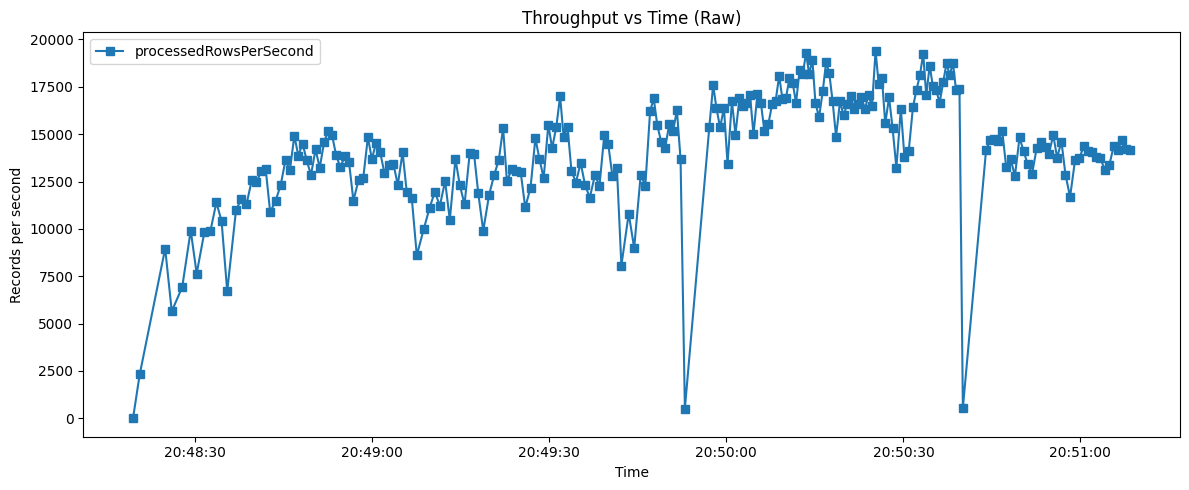

In [317]:
# --------------------------------------------------
# 6. Plot raw throughput
# --------------------------------------------------
plt.figure(figsize=(12, 5))

#plt.plot(df["timestamp"], df["throughput_rps"], marker="o", label="throughput_rps")
#plt.plot(df["timestamp"], df["inputRowsPerSecond"], marker="x", label="inputRowsPerSecond")
plt.plot(df["timestamp"], df["processedRowsPerSecond"], marker="s", label="processedRowsPerSecond")

plt.title("Throughput vs Time (Raw)")
plt.xlabel("Time")
plt.ylabel("Records per second")
plt.legend()
plt.tight_layout()
plt.show()

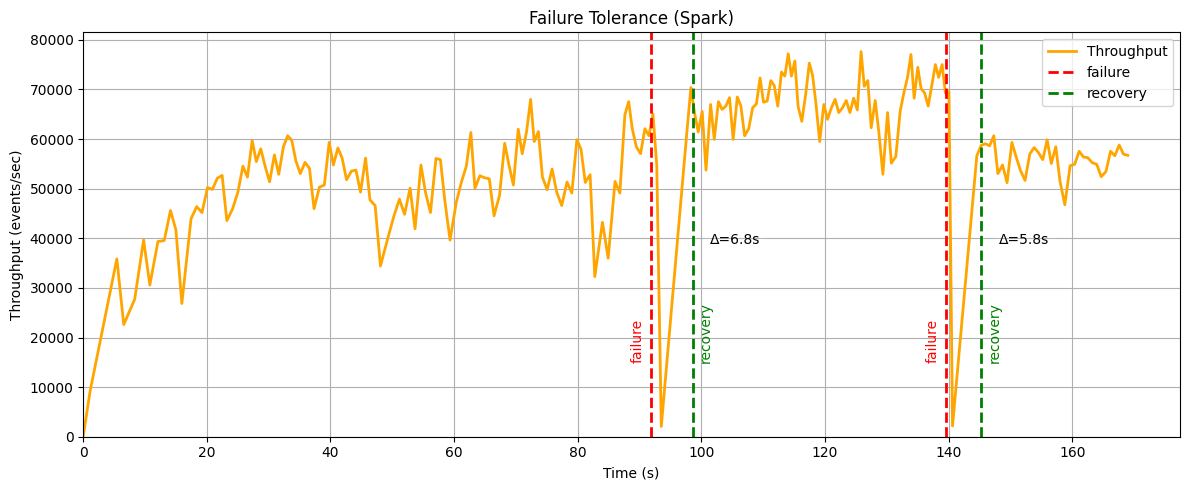

In [364]:
# --------------------------------------------------
# 7. Plot smoothed throughput
# --------------------------------------------------
plt.figure(figsize=(12, 5))

#plt.plot(df["timestamp"], df["throughput_smooth"], linewidth=2, label="throughput_rps (EMA)")
#plt.plot(df["timestamp"], df["input_smooth"], linewidth=2, label="inputRowsPerSecond (EMA)")
#plt.plot(df["timestamp"], df["processed_smooth"], linewidth=2, label="processedRowsPerSecond (EMA)")
plt.plot(df["time_sec"], df["processed_smooth"], label="Throughput",color="orange", linewidth=2)
#plt.plot(df["time_sec"], df["processed_smooth_2"], label="processedRowsPerSecond")

fail_t = 91.8   # seconds
rec_t = 98.6   # seconds
plt.axvline(fail_t, color="red", linestyle="--", linewidth=2, label="failure")

plt.text(
    fail_t - 1,   # shift left (adjust value as needed)
    df["processed_smooth"].max() * 0.2,
    "failure",
    rotation=90,
    color="red",
    ha="right"
)

# -------------------------
# RECOVERY MARKER
# -------------------------
plt.axvline(rec_t, color="green", linestyle="--", linewidth=2, label="recovery")

plt.text(
    rec_t + 1,
    df["processed_smooth"].max() * 0.2,
    "recovery",
    rotation=90,
    color="green"
)

# -------------------------
# RECOVERY DELTA (optional)
# -------------------------
delta = rec_t - fail_t

plt.text(
    rec_t + 11,  # shift right outside region
    df["processed_smooth"].max() * 0.5,
    f"Δ={delta:.1f}s",
    ha="right",
    bbox=dict(facecolor="white", alpha=0.1, edgecolor="none")
)

######## second
fail_t_t = 139.5   # seconds
rec_t_t = 145.3   # seconds

plt.axvline(fail_t_t, color="red", linestyle="--", linewidth=2)

plt.text(
    fail_t_t - 1,   # shift left (adjust value as needed)
    df["processed_smooth"].max() * 0.2,
    "failure",
    rotation=90,
    color="red",
    ha="right"
)

# -------------------------
# RECOVERY MARKER
# -------------------------
plt.axvline(rec_t_t, color="green", linestyle="--", linewidth=2)

plt.text(
    rec_t_t + 1,
    df["processed_smooth"].max() * 0.2,
    "recovery",
    rotation=90,
    color="green"
)

# -------------------------
# RECOVERY DELTA (optional)
# -------------------------
delta = rec_t_t - fail_t_t

plt.text(
    rec_t_t + 11,  # shift right outside region
    df["processed_smooth"].max() * 0.5,
    f"Δ={delta:.1f}s",
    ha="right",
    bbox=dict(facecolor="white", alpha=0.1, edgecolor="none")
)




#########


plt.title("Failure Tolerance (Spark)")
plt.xlabel("Time (s)")
plt.ylabel("Throughput (events/sec)")
plt.grid(True)
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.legend()
plt.tight_layout()
plt.savefig("figures/figures_m10k_q1/failure_spark.png", dpi=300, bbox_inches="tight")
plt.show()

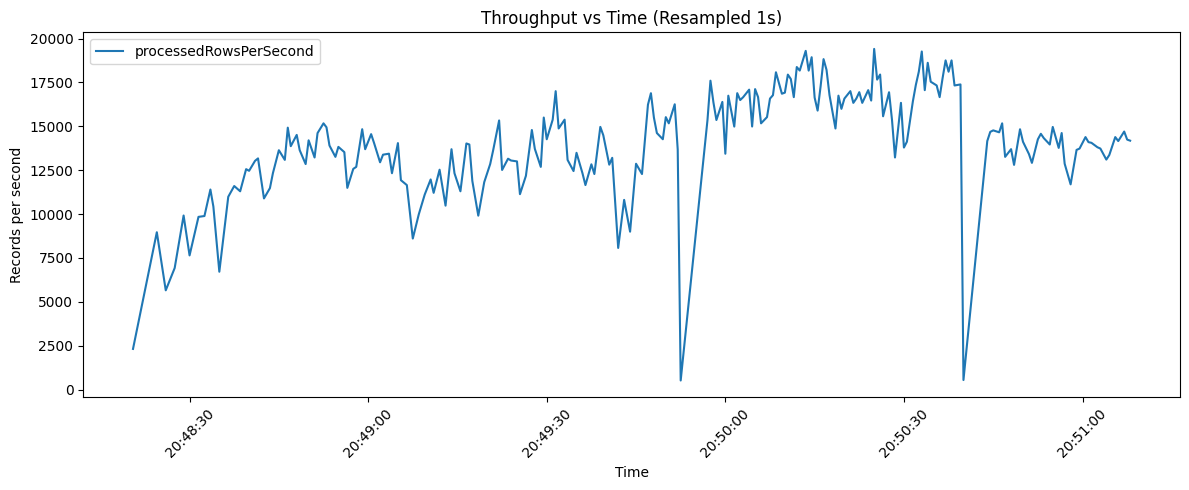

In [247]:
# --------------------------------------------------
# 8. Plot resampled throughput (best for analysis)
# --------------------------------------------------
plt.figure(figsize=(12, 5))

#plt.plot(df_resampled.index, df_resampled["throughput_rps"], label="throughput_rps")
#plt.plot(df_resampled.index, df_resampled["inputRowsPerSecond"], label="inputRowsPerSecond")
plt.plot(df_resampled.index, df_resampled["processedRowsPerSecond"], label="processedRowsPerSecond")

plt.title("Throughput vs Time (Resampled 1s)")
plt.xlabel("Time")
plt.ylabel("Records per second")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()